# Notebook 5. Feedback loop analysis: organic vs non-organic SASRec

Итак, в этом ноутбуке финальная SASRec-конфигурация используется для анализа различий между organic и non-organic взаимодействиями.

Идея заключается в следующем: я обучаю две модели с одинаковой архитектурой и одинаковыми параметрами, но на разных частях train history. Первая модель обучается только на organic interactions, вторая - только на non-organic interactions. После этого обе модели оцениваются в одной leave-one-out постановке. Такой дизайн нужен, чтобы сравнить не только качество предсказания следующего трека, но и свойства рекомендаций: покрытие каталога, концентрацию выдачи и смещение в сторону популярных треков.

## 1. Импорты и загрузка данных

Сначала загружается финальный сабсэмпл и фиксируются параметры запуска. В этом ноутбуке состав данных уже не меняется: дальше меняется только тип train history, на котором обучается SASRec.

In [ ]:
!pip install -q tqdm pyarrow

In [ ]:
import os
import json
import time
import random
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.options.display.max_columns = 180
pd.options.display.max_rows = 180
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: cuda


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/Курсовая/final_subsample"
# загружаю финальный сабсэмпл
final_events = pd.read_parquet(f"{DATA_DIR}/final_events.parquet")

final_events['timestamp'] = pd.to_numeric(final_events['timestamp'], errors='coerce')
final_events = final_events.dropna(subset=['timestamp'])
final_events['timestamp'] = final_events['timestamp'].astype('int64')

final_events['is_organic'] = final_events['is_organic'].astype(int)
final_events['played_ratio_pct'] = pd.to_numeric(final_events['played_ratio_pct'], errors='coerce')

final_events = (final_events.drop_duplicates(subset=['uid', 'item_id', 'timestamp']).sort_values(['uid', 'timestamp']).reset_index(drop=True))

print('events:', final_events.shape)
print('users:', final_events['uid'].nunique())
print('items:', final_events['item_id'].nunique())
print('organic share:', round(final_events['is_organic'].mean(), 4))

final_events.head()

Mounted at /content/drive
events: (10206636, 5)
users: 4998
items: 300000
organic share: 0.5094


,uid,item_id,timestamp,is_organic,played_ratio_pct
0,100,1441281,39420,0,100.0
1,100,3397170,40360,0,46.0
2,100,1449307,40640,0,100.0
3,100,2996197,40885,0,100.0
4,100,6474571,41130,0,100.0


## 2. Leave-one-out split

Здесь используется та же схема оценки, что и в предыдущих ноутбуках: последнее событие пользователя становится test target, предпоследнее - validation target, все более ранние события формируют train history. После этого оставляются только warm-start пользователи и треки, которые встречаются в train vocabulary.


In [ ]:
def build_leave_one_out_split(events: pd.DataFrame, min_events: int = 3):
    df = events.sort_values(["uid", "timestamp"]).copy()
    lengths = df.groupby("uid")["item_id"].transform("size")
    df = df[lengths >= min_events].copy()
    df["pos"] = df.groupby("uid").cumcount()
    df["n_events"] = df.groupby("uid")["item_id"].transform("size")

    train = df[df["pos"] < df["n_events"] - 2].copy()
    val = df[df["pos"] == df["n_events"] - 2].copy()
    test = df[df["pos"] == df["n_events"] - 1].copy()
    return train, val, test

In [ ]:
# строю leave-one-out split на финальном сабсэмпле
train_events, val_events, test_events = build_leave_one_out_split(final_events, min_events=3)

train_users = set(train_events["uid"].unique())
train_items = set(train_events["item_id"].unique())

In [ ]:
val_events = val_events[val_events["uid"].isin(train_users) & val_events["item_id"].isin(train_items)].copy()
valid_val_users = set(val_events["uid"].unique())

test_events = test_events[test_events["uid"].isin(valid_val_users) & test_events["item_id"].isin(train_items)].copy()
test_users = set(test_events["uid"].unique())

val_events = val_events[val_events["uid"].isin(test_users)].copy()
train_events_eval = train_events[train_events["uid"].isin(test_users)].copy()

In [ ]:
split_summary = pd.DataFrame({
    "part": ["train_events", "validation_targets", "test_targets"],
    "rows": [len(train_events_eval), len(val_events), len(test_events)],
    "users": [train_events_eval["uid"].nunique(), val_events["uid"].nunique(), test_events["uid"].nunique()],
    "items": [train_events_eval["item_id"].nunique(), val_events["item_id"].nunique(), test_events["item_id"].nunique()],
    "organic_share": [train_events_eval["is_organic"].mean(), val_events["is_organic"].mean(), test_events["is_organic"].mean()],
})

split_summary

,part,rows,users,items,organic_share
0,train_events,10196170,4973,299841,0.509368
1,validation_targets,4973,4973,3806,0.548763
2,test_targets,4973,4973,3846,0.552986


## 3. Organic и non-organic трейн-истории

После построения общего train split я разделяю обучающие события на две части: organic interactions и non-organic interactions Validation и test targets остаются общими. Это позволяет сравнивать модели не на разных тестах, а на одной и той же задаче предсказания следующего трека.

In [ ]:
# разделяю train history по типу взаимодействия
organic_train_events = train_events_eval[train_events_eval["is_organic"] == 1].copy()
nonorganic_train_events = train_events_eval[train_events_eval["is_organic"] == 0].copy()

In [ ]:
train_subset_summary = pd.DataFrame([
    {
        "subset": "organic_train",
        "events": len(organic_train_events),
        "users": organic_train_events["uid"].nunique(),
        "items": organic_train_events["item_id"].nunique(),
        "mean_played_ratio": organic_train_events["played_ratio_pct"].mean(),
        "median_played_ratio": organic_train_events["played_ratio_pct"].median(),
    },
    {
        "subset": "nonorganic_train",
        "events": len(nonorganic_train_events),
        "users": nonorganic_train_events["uid"].nunique(),
        "items": nonorganic_train_events["item_id"].nunique(),
        "mean_played_ratio": nonorganic_train_events["played_ratio_pct"].mean(),
        "median_played_ratio": nonorganic_train_events["played_ratio_pct"].median(),
    },
])

train_subset_summary

,subset,events,users,items,mean_played_ratio,median_played_ratio
0,organic_train,5193598,4763,236371,60.237481,99.0
1,nonorganic_train,5002572,4715,162360,69.695643,100.0


**Вывод:** Organic и non-organic train histories различаются по числу событий и покрытию пользователей. Это важно учитывать при интерпретации: модели сравниваются в одной задаче, но обучающий сигнал у них разный по природе и объёму.

## 4. Dataset utilities

In [ ]:
MAX_LEN = 100
MAX_TRAIN_SAMPLES_PER_USER = 75
BATCH_SIZE = 128
EVAL_KS = (10, 50)
MAIN_K = 50

SASREC_CONFIG = {
    'max_len': MAX_LEN,
    'max_train_samples_per_user': MAX_TRAIN_SAMPLES_PER_USER,
    'batch_size': BATCH_SIZE,
    'hidden_dim': 128,
    'num_heads': 2,
    'num_layers': 1,
    'dropout': 0.2,
    'lr': 5e-4,
    'weight_decay': 1e-5,
    'grad_clip': 1.0,
    'epochs': 30,
}

SASREC_CONFIG

{'max_len': 100,
 'max_train_samples_per_user': 75,
 'batch_size': 128,
 'hidden_dim': 128,
 'num_heads': 2,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.0005,
 'weight_decay': 1e-05,
 'grad_clip': 1.0,
 'epochs': 30}

In [ ]:
def pad_sequence(seq, max_len, pad_value=0):
    seq = seq[-max_len:]
    return [pad_value] * (max_len - len(seq)) + seq

In [ ]:
def build_sequence_samples_for_feedback(
    train_subset: pd.DataFrame,
    val_events: pd.DataFrame,
    test_events: pd.DataFrame,
    item2idx: dict,
    max_len: int = 100,
    max_train_samples_per_user: int = 75,
    min_train_history: int = 1,
):
    # Обучающие последовательности строятся только по выбранному типу train history.
    train_encoded = train_subset.sort_values(['uid', 'timestamp']).copy()
    train_encoded = train_encoded[train_encoded['item_id'].isin(item2idx)].copy()
    train_encoded['item_idx'] = train_encoded['item_id'].map(item2idx).astype(int)

    # Validation/test target мапятся в общий train vocabulary.
    val_encoded = val_events[val_events['item_id'].isin(item2idx)].copy()
    val_encoded['target_idx'] = val_encoded['item_id'].map(item2idx).astype(int)

    test_encoded = test_events[test_events['item_id'].isin(item2idx)].copy()
    test_encoded['target_idx'] = test_encoded['item_id'].map(item2idx).astype(int)

    user_train_seq = train_encoded.groupby('uid')['item_idx'].apply(list).to_dict()
    user_val_target = dict(zip(val_encoded['uid'], val_encoded['target_idx']))
    user_test_target = dict(zip(test_encoded['uid'], test_encoded['target_idx']))

    train_samples, val_samples, test_samples = [], [], []

    for uid, seq in user_train_seq.items():
        if len(seq) >= 2:
            start_i = max(1, len(seq) - max_train_samples_per_user)
            for i in range(start_i, len(seq)):
                train_samples.append({'uid': uid, 'input_seq': pad_sequence(seq[:i], max_len), 'target': seq[i]})

        if uid in user_val_target and len(seq) >= min_train_history:
            val_samples.append({'uid': uid, 'input_seq': pad_sequence(seq, max_len), 'target': user_val_target[uid]})

        if uid in user_test_target and uid in user_val_target and len(seq) >= min_train_history:
            test_input = seq + [user_val_target[uid]]
            test_samples.append({'uid': uid, 'input_seq': pad_sequence(test_input, max_len), 'target': user_test_target[uid]})

    return pd.DataFrame(train_samples), pd.DataFrame(val_samples), pd.DataFrame(test_samples)


In [ ]:
class SeqRecDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.uids = df['uid'].tolist()
        self.inputs = df['input_seq'].tolist()
        self.targets = df['target'].tolist()

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            self.uids[idx],
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.targets[idx], dtype=torch.long),
        )


def collate_seqrec(batch):
    uids = [x[0] for x in batch]
    inputs = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    return uids, inputs, targets


def build_feedback_dataloaders(
    train_subset,
    val_events,
    test_events,
    item2idx,
    max_len=100,
    max_train_samples_per_user=75,
    batch_size=128,
):
    idx2item = {idx: item_id for item_id, idx in item2idx.items()}
    num_items = len(item2idx) + 1

    train_df, val_df, test_df = build_sequence_samples_for_feedback(
        train_subset=train_subset,
        val_events=val_events,
        test_events=test_events,
        item2idx=item2idx,
        max_len=max_len,
        max_train_samples_per_user=max_train_samples_per_user,
    )

    train_loader = DataLoader(
        SeqRecDataset(train_df),
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_seqrec,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        SeqRecDataset(val_df),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_seqrec,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        SeqRecDataset(test_df),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_seqrec,
        pin_memory=torch.cuda.is_available(),
    )

    info = {
        'num_items': num_items,
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
        'train_users': train_df['uid'].nunique() if len(train_df) else 0,
        'val_users': val_df['uid'].nunique() if len(val_df) else 0,
        'test_users': test_df['uid'].nunique() if len(test_df) else 0,
        'train_batches': len(train_loader),
        'val_batches': len(val_loader),
        'test_batches': len(test_loader),
    }

    return train_loader, val_loader, test_loader, idx2item, num_items, info, train_df, val_df, test_df

## 5. SASRec архитектура и обучение

Архитектура соответствует финальному SASRec из Notebook 4: item embeddings, positional embeddings, causal self-attention и softmax по общему train vocabulary. Для feedback loop анализа меняется только состав train history, а сама модель остается одинаковой для обеих подвыборок.


In [ ]:
class SASRec(nn.Module):
    def __init__(self, num_items, max_len, hidden_dim=128, num_heads=2, num_layers=1, dropout=0.2, padding_idx=0):
        super().__init__()
        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.padding_idx = padding_idx

        self.item_embedding = nn.Embedding(num_items, hidden_dim, padding_idx=padding_idx)
        self.position_embedding = nn.Embedding(max_len, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def encode(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        h = self.item_embedding(x) + self.position_embedding(positions)
        h = self.dropout(h)

        padding_mask = x.eq(self.padding_idx)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool), diagonal=1)
        h = self.encoder(h, mask=causal_mask, src_key_padding_mask=padding_mask)
        h = self.layer_norm(h)

        lengths = (~padding_mask).sum(dim=1).clamp(min=1)
        last_idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_dim)
        return h.gather(dim=1, index=last_idx).squeeze(1)

    def forward(self, x):
        user_repr = self.encode(x)
        logits = user_repr @ self.item_embedding.weight.T
        logits[:, self.padding_idx] = -1e9
        return logits


In [ ]:
def ranking_sums_at_k(logits, targets, k):
    topk = torch.topk(logits, k=k, dim=1).indices

    hits = 0.0
    ndcg_sum = 0.0
    mrr_sum = 0.0

    for i in range(targets.size(0)):
        preds = topk[i].tolist()
        target = targets[i].item()

        if target in preds:
            rank = preds.index(target) + 1
            hits += 1.0
            ndcg_sum += 1.0 / np.log2(rank + 1)
            mrr_sum += 1.0 / rank

    return hits, ndcg_sum, mrr_sum


@torch.no_grad()
def evaluate_model(model, loader, ks=(10, 50)):
    model.eval()
    total = 0
    hits = {k: 0.0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    mrrs = {k: 0.0 for k in ks}

    for uids, x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        total += y.size(0)

        for k in ks:
            batch_hits, batch_ndcg, batch_mrr = ranking_sums_at_k(logits, y, k)
            hits[k] += batch_hits
            ndcgs[k] += batch_ndcg
            mrrs[k] += batch_mrr

    out = {}
    for k in ks:
        recall = hits[k] / max(1, total)
        out[f'Recall@{k}'] = recall
        out[f'Precision@{k}'] = recall / k
        out[f'NDCG@{k}'] = ndcgs[k] / max(1, total)
        out[f'MRR@{k}'] = mrrs[k] / max(1, total)
    return out


def train_one_epoch(model, loader, optimizer, criterion, grad_clip=1.0):
    model.train()
    loss_sum = 0.0
    used_batches = 0
    start = time.time()

    for uids, x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        loss_sum += loss.item()
        used_batches += 1

    return loss_sum / max(1, used_batches), time.time() - start, used_batches


def train_sasrec_feedback_model(name, train_loader, val_loader, num_items, config, patience=6):
    model = SASRec(
        num_items=num_items,
        max_len=config['max_len'],
        hidden_dim=config['hidden_dim'],
        num_heads=config['num_heads'],
        num_layers=config['num_layers'],
        dropout=config['dropout'],
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_recall50 = -1
    best_epoch = 0
    no_improve = 0
    history = []

    for epoch in range(config['epochs']):
        train_loss, epoch_time, used_batches = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            grad_clip=config['grad_clip'],
        )
        val_metrics = evaluate_model(model, val_loader, ks=EVAL_KS)
        current_val = val_metrics['Recall@50']

        row = {
            'model_variant': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'epoch_time_sec': epoch_time,
            'used_batches': used_batches,
            **{f'val_{k}': v for k, v in val_metrics.items()},
        }
        history.append(row)

        if current_val > best_val_recall50:
            best_val_recall50 = current_val
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        print(f'{name} | epoch {epoch + 1}/{config["epochs"]}')
        print(f'train loss: {train_loss:.4f}')
        print(f'time sec: {epoch_time:.2f}')
        print('val:', val_metrics)
        print(f'best epoch: {best_epoch}, best val Recall@50: {best_val_recall50:.5f}')

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        'model_variant': name,
        'best_epoch': best_epoch,
        'best_val_Recall@50': best_val_recall50,
        'planned_epochs': config['epochs'],
        'hidden_dim': config['hidden_dim'],
        'num_heads': config['num_heads'],
        'num_layers': config['num_layers'],
        'dropout': config['dropout'],
        'lr': config['lr'],
        'weight_decay': config['weight_decay'],
        'max_len': config['max_len'],
        'max_train_samples_per_user': config['max_train_samples_per_user'],
    }
    return model, pd.DataFrame(history), result


## 6. Подготовка даталоадеров

Для обеих моделей используется общий train vocabulary из полного train history. Это важно для честного сравнения: organic-only и non-organic-only модели получают разные обучающие последовательности, но ранжируют элементы из одного и того же каталога.


In [ ]:
common_item_ids = train_events_eval['item_id'].drop_duplicates().tolist()
common_item2idx = {item_id: idx + 1 for idx, item_id in enumerate(common_item_ids)}

(
    organic_train_loader,
    organic_val_loader,
    organic_test_loader,
    organic_idx2item,
    organic_num_items,
    organic_info,
    organic_train_df,
    organic_val_df,
    organic_test_df,
) = build_feedback_dataloaders(
    train_subset=organic_train_events,
    val_events=val_events,
    test_events=test_events,
    item2idx=common_item2idx,
    max_len=MAX_LEN,
    max_train_samples_per_user=MAX_TRAIN_SAMPLES_PER_USER,
    batch_size=BATCH_SIZE,
)

(
    nonorganic_train_loader,
    nonorganic_val_loader,
    nonorganic_test_loader,
    nonorganic_idx2item,
    nonorganic_num_items,
    nonorganic_info,
    nonorganic_train_df,
    nonorganic_val_df,
    nonorganic_test_df,
) = build_feedback_dataloaders(
    train_subset=nonorganic_train_events,
    val_events=val_events,
    test_events=test_events,
    item2idx=common_item2idx,
    max_len=MAX_LEN,
    max_train_samples_per_user=MAX_TRAIN_SAMPLES_PER_USER,
    batch_size=BATCH_SIZE,
)

feedback_dataset_info = pd.DataFrame([
    {'variant': 'organic_only', **organic_info},
    {'variant': 'nonorganic_only', **nonorganic_info},
])

feedback_dataset_info

,variant,num_items,train_samples,val_samples,test_samples,train_users,val_users,test_users,train_batches,val_batches,test_batches
0,organic_only,299842,324565,4763,4763,4734,4763,4763,2536,38,38
1,nonorganic_only,299842,314268,4715,4715,4665,4715,4715,2456,37,37


## 7. Обучение моделей

Обе модели обучаются с одинаковыми гиперпараметрами. Единственное отличие заключаетмся лишь в типе событий, из которых собрана train history. Лучшая эпоха внутри каждого запуска выбирается по validation Recall@50.


In [ ]:
RUN_TRAINING = True

if RUN_TRAINING:
    organic_model, organic_history, organic_result = train_sasrec_feedback_model(
        name="SASRec_organic_only",
        train_loader=organic_train_loader,
        val_loader=organic_val_loader,
        num_items=organic_num_items,
        config=SASREC_CONFIG,
        patience=6,
    )

    nonorganic_model, nonorganic_history, nonorganic_result = train_sasrec_feedback_model(
        name="SASRec_nonorganic_only",
        train_loader=nonorganic_train_loader,
        val_loader=nonorganic_val_loader,
        num_items=nonorganic_num_items,
        config=SASREC_CONFIG,
        patience=6,
    )

/tmp/ipykernel_19444/1016226263.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  0%|          | 0/2536 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

SASRec_organic_only | epoch 1/30
train loss: 15.8093
time sec: 31.88
val: {'Recall@10': 0.0516481209321856, 'Precision@10': 0.00516481209321856, 'NDCG@10': np.float64(0.04181144605742275), 'MRR@10': 0.038873142510555896, 'Recall@50': 0.07852193995381063, 'Precision@50': 0.0015704387990762125, 'NDCG@50': np.float64(0.04752547788371716), 'MRR@50': 0.03997494729851289}
best epoch: 1, best val Recall@50: 0.07852


  0%|          | 0/2536 [00:00<?, ?it/s]

...

  0%|          | 0/37 [00:00<?, ?it/s]

SASRec_nonorganic_only | epoch 29/30
train loss: 7.5976
time sec: 29.81
val: {'Recall@10': 0.032025450689289504, 'Precision@10': 0.0032025450689289504, 'NDCG@10': np.float64(0.01736076337354534), 'MRR@10': 0.012956201922267672, 'Recall@50': 0.10031813361611877, 'Precision@50': 0.0020063626723223755, 'NDCG@50': np.float64(0.031775006335894876), 'MRR@50': 0.01565241532043675}
best epoch: 28, best val Recall@50: 0.10095


  0%|          | 0/2456 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

SASRec_nonorganic_only | epoch 30/30
train loss: 7.5422
time sec: 29.85
val: {'Recall@10': 0.03138918345705196, 'Precision@10': 0.003138918345705196, 'NDCG@10': np.float64(0.017411087538431017), 'MRR@10': 0.01322324900267636, 'Recall@50': 0.09840933191940615, 'Precision@50': 0.001968186638388123, 'NDCG@50': np.float64(0.03165129767431755), 'MRR@50': 0.015919916032458577}
best epoch: 28, best val Recall@50: 0.10095


## 8. Сравнение качества

перейдем теперь непосредственно к сравнению релультатов обучения модлей на двух подвыборках:

In [ ]:
organic_test_metrics = evaluate_model(organic_model, organic_test_loader, ks=EVAL_KS)
nonorganic_test_metrics = evaluate_model(nonorganic_model, nonorganic_test_loader, ks=EVAL_KS)

quality_results = pd.DataFrame([
    {
        **organic_result,
        **organic_test_metrics,
        'test_samples': organic_info['test_samples'],
        'train_samples': organic_info['train_samples'],
        'num_items': organic_info['num_items'],
    },
    {
        **nonorganic_result,
        **nonorganic_test_metrics,
        'test_samples': nonorganic_info['test_samples'],
        'train_samples': nonorganic_info['train_samples'],
        'num_items': nonorganic_info['num_items'],
    }])

quality_results

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

,model_variant,best_epoch,best_val_Recall@50,planned_epochs,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,max_len,max_train_samples_per_user,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@50,Precision@50,NDCG@50,MRR@50,test_samples,train_samples,num_items
0,SASRec_organic_only,30,0.243334,30,128,2,1,0.2,0.0005,0.00001,100,75,0.17384,0.017384,0.111169,0.091832,0.254671,0.005093,0.129437,0.095947,4763,324565,299842
1,SASRec_nonorganic_only,28,0.100954,30,128,2,1,0.2,0.0005,0.00001,100,75,0.04878,0.004878,0.030282,0.024771,0.113256,0.002265,0.044046,0.027486,4715,314268,299842


**Вывод:**  Модель, обученная только на organic interactions, заметно лучше по всем ranking-метрикам. У неё выше validation Recall@50 и test-качество, поэтому organic history даёт более сильный сигнал для предсказания следующего трека. Non-organic-only модель тоже обучается, но её качество ниже: вероятно, такие взаимодействия хуже отражают устойчивые пользовательские предпочтения и сильнее зависят от внешнего механизма показа. Это подтверждает, что organic и non-organic события лучше анализировать отдельно, а не воспринимать как полностью одинаковый обучающий сигнал.

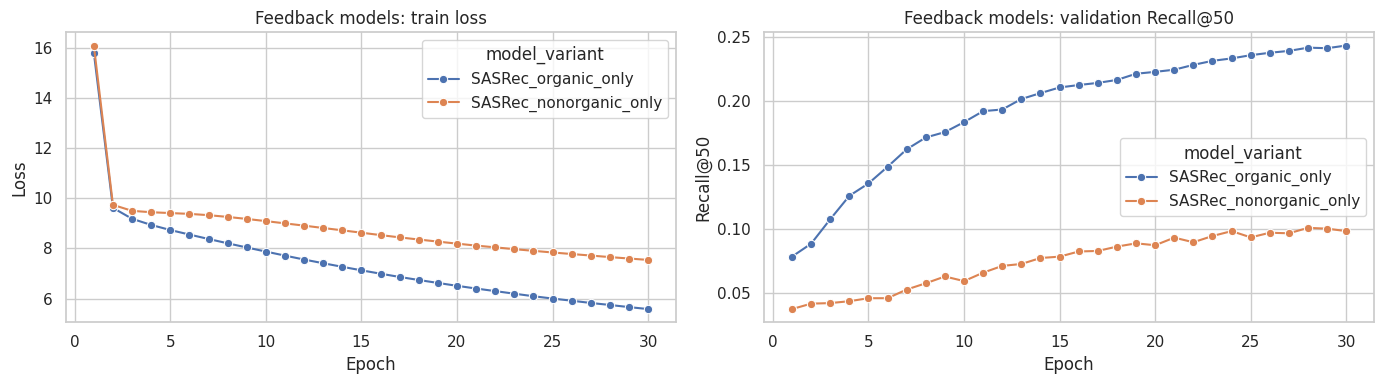

In [ ]:
all_histories = pd.concat([organic_history, nonorganic_history], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=all_histories, x='epoch', y='train_loss', hue='model_variant', marker='o', ax=axes[0])
axes[0].set_title('Feedback models: train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

sns.lineplot(data=all_histories, x='epoch', y='val_Recall@50', hue='model_variant', marker='o', ax=axes[1])
axes[1].set_title('Feedback models: validation Recall@50')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall@50')

plt.tight_layout()
plt.show()

**Вывод:**  Итак, кривые обучения подтверждают разницу между двумя типами сигналов. У organic-only модели train loss стабильно снижается, а validation Recall@50 растёт почти на всём интервале обучения, поэтому модель продолжает извлекать полезную информацию из последовательностей. У non-organic-only модели качество тоже немного растёт, но заметно медленнее и выходит на более низкий уровень. Это показывает, что non-organic взаимодействия сами по себе дают более слабый и менее устойчивый сигнал для next-track prediction.

## 9. Генерация рекомендаций

После обучения для каждого пользователя формируется top-50 список рекомендаций. Эти списки используются не только для попадания в target, но и для расчета coverage, Gini и концентрации на популярных треках.


In [ ]:
@torch.no_grad()
def generate_topk_recommendations(model, loader, idx2item, top_k=50):
    model.eval()
    rows = []

    for uids, x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        topk = torch.topk(logits, k=top_k, dim=1).indices.cpu().numpy()
        targets = y.cpu().numpy()

        for uid, target_idx, rec_idxs in zip(uids, targets, topk):
            target_item = idx2item.get(int(target_idx), None)
            rec_items = [idx2item.get(int(idx), None) for idx in rec_idxs]
            rec_items = [item for item in rec_items if item is not None]
            rows.append({
                'uid': uid,
                'target_idx': int(target_idx),
                'target_item': target_item,
                'recommendations': rec_items,
            })

    return pd.DataFrame(rows)

In [ ]:
organic_recs = generate_topk_recommendations(organic_model, organic_test_loader, organic_idx2item, top_k=MAIN_K)
nonorganic_recs = generate_topk_recommendations(nonorganic_model, nonorganic_test_loader, nonorganic_idx2item, top_k=MAIN_K)

organic_recs['model_variant'] = 'SASRec_organic_only'
nonorganic_recs['model_variant'] = 'SASRec_nonorganic_only'

recommendations_df = pd.concat([organic_recs, nonorganic_recs], ignore_index=True)
recommendations_df.head()

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

,uid,target_idx,target_item,recommendations,model_variant
0,100,293,7415847,"[1143002, 1912005, 155792, 410868, 2419677, 17...",SASRec_organic_only
1,200,355,2859641,"[8729910, 500245, 4119982, 3763080, 2859641, 3...",SASRec_organic_only
2,300,60580,8033345,"[6246552, 5805912, 7247939, 8600877, 4094586, ...",SASRec_organic_only
3,600,778,5148775,"[1441281, 3397170, 1449307, 2996197, 6474571, ...",SASRec_organic_only
4,700,14457,2439431,"[7801891, 2627621, 2518515, 2188783, 1102135, ...",SASRec_organic_only


## 10. Popularity reference

В этом блоке я фиксирую общий reference по популярности треков. Для каждого трека считается число появлений в train-части, затем треки разбиваются на 10 popularity bins: от наименее популярных к наиболее популярным.

In [ ]:
item_popularity = train_events_eval.groupby("item_id").size().rename("train_popularity").reset_index()
item_popularity["log_popularity"] = np.log1p(item_popularity["train_popularity"])
item_popularity["popularity_bin"] = pd.qcut(item_popularity["log_popularity"].rank(method="first"), q=10, labels=False, duplicates="drop",).astype(int)

In [ ]:
popularity_map = dict(zip(item_popularity["item_id"], item_popularity["train_popularity"]))
popularity_bin_map = dict(zip(item_popularity["item_id"], item_popularity["popularity_bin"]))
catalog_size = train_events_eval["item_id"].nunique()
n_users_reference = train_events_eval["uid"].nunique()

item_popularity.head()

,item_id,train_popularity,log_popularity,popularity_bin
0,81,1,0.693147,0
1,127,2,1.098612,3
2,142,1,0.693147,0
3,167,2,1.098612,3
4,206,412,6.023448,9


Таблица с бинами популярности построен по train-части и дальше используется как единая шкала для анализа popularity bias. Это важно, потому что обе feedback-модели сравниваются относительно одного и того же распределения популярности треков.

## 11. Метрики покрытия, разнообразия и popularity bias

В этом блоке считаются метрики по самим рекомендательным спискам, а не по попаданию в следующий трек. Они показывают, насколько широко модель покрывает каталог, насколько разнообразной получается выдача и насколько рекомендации сконцентрированы вокруг популярных треков.

Используются следующие метрики:

- Catalog Coverage@K - доля каталога, которая хотя бы раз попала в рекомендации
- Unique Recommended Items@K - число уникальных треков в рекомендациях
- Gini@K - степень концентрации рекомендаций на ограниченном наборе треков
- Entropy@K —-разнообразие распределения рекомендаций
- Top Popularity Bin Share@K - доля рекомендаций из самых популярных popularity bins.

In [ ]:
def gini_from_counts(counts):
    values = np.array(list(counts), dtype=float)
    if len(values) == 0:
        return np.nan
    if np.all(values == 0):
        return 0.0
    values = np.sort(values)
    n = len(values)
    cum_values = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cum_values) / cum_values[-1]) / n

In [ ]:
def entropy_from_counts(counts):
    values = np.array(list(counts), dtype=float)
    if len(values) == 0 or values.sum() == 0:
        return np.nan
    probs = values / values.sum()
    return -np.sum(probs * np.log2(probs + 1e-12))

In [ ]:
def flatten_recommendations(recs_series, k=50):
    flat = []
    for recs in recs_series:
        flat.extend(recs[:k])
    return flat

In [ ]:
def recommendation_exposure_metrics(
    recs_df,
    model_variant,
    popularity_map,
    popularity_bin_map,
    catalog_size,
    n_users_reference,
    ks=(10, 50),
):
    rows = []
    subset = recs_df[recs_df['model_variant'] == model_variant].copy()

    for k in ks:
        flat_recs = flatten_recommendations(subset['recommendations'], k=k)
        counts = Counter(flat_recs)
        unique_recs = len(counts)
        total_recs = len(flat_recs)

        popularities = np.array([popularity_map.get(item, 0) for item in flat_recs], dtype=float)
        bins = np.array([popularity_bin_map.get(item, -1) for item in flat_recs], dtype=int)

        rows.append({
            'model_variant': model_variant,
            'K': k,
            'total_recommendations': total_recs,
            'Unique Recommended Items@K': unique_recs,
            'Catalog Coverage@K': unique_recs / max(1, catalog_size),
            'Gini@K': gini_from_counts(counts.values()),
            'Top Popularity Bin Share@K': np.mean(bins >= 8) if len(bins) else np.nan,
            'mean_item_popularity': np.mean(popularities) if len(popularities) else np.nan,
            'median_item_popularity': np.median(popularities) if len(popularities) else np.nan,
            'long_tail_30pct_bin_share': np.mean(bins <= 2) if len(bins) else np.nan,
            'recommendation_entropy': entropy_from_counts(counts.values()),
            'mean_novelty': np.mean(-np.log2((popularities + 1) / (n_users_reference + 1))) if len(popularities) else np.nan,
        })

    return pd.DataFrame(rows)


In [ ]:
diversity_results = pd.concat([recommendation_exposure_metrics(
        recommendations_df,
        'SASRec_organic_only',
        popularity_map,
        popularity_bin_map,
        catalog_size,
        n_users_reference,
        ks=EVAL_KS,
    ), recommendation_exposure_metrics(
        recommendations_df,
        'SASRec_nonorganic_only',
        popularity_map,
        popularity_bin_map,
        catalog_size,
        n_users_reference,
        ks=EVAL_KS,),], ignore_index=True)

diversity_results

,model_variant,K,total_recommendations,Unique Recommended Items@K,Catalog Coverage@K,Gini@K,Top Popularity Bin Share@K,mean_item_popularity,median_item_popularity,long_tail_30pct_bin_share,recommendation_entropy,mean_novelty
0,SASRec_organic_only,10,47630,17922,0.059772,0.568722,0.910771,2014.153979,681.0,0.009112,12.367876,3.436260
1,SASRec_organic_only,50,238150,39085,0.130352,0.745195,0.922011,1988.857077,785.0,0.011568,12.857830,3.237500
2,SASRec_nonorganic_only,10,47150,7735,0.025797,0.735768,0.973340,2156.081421,1146.0,0.004411,10.753078,2.443107
3,SASRec_nonorganic_only,50,235750,18327,0.061122,0.814425,0.969349,1931.355563,1006.0,0.004730,11.688451,2.661864


**Вывод:**  По метрикам покрытия organic-only модель выглядит заметно лучше: она рекомендует больше уникальных треков и покрывает большую долю каталога как на @10, так и на @50. При этом у неё ниже Gini@K и выше recommendation entropy, то есть выдача менее сконцентрирована на небольшом наборе треков. Non-organic-only модель, наоборот, сильнее сжимает рекомендации вокруг популярных позиций: у неё выше Top Popularity Bin Share@K и ниже доля long-tail треков. Это означает, что organic-сигнал не только даёт лучшее качество предсказания, но и формирует более разнообразные рекомендации.

## 12. Распределение по бинам популярности

In [ ]:
def recommendation_bin_distribution(recs_df, model_variant, popularity_bin_map, k=50):
    subset = recs_df[recs_df["model_variant"] == model_variant].copy()
    flat_recs = flatten_recommendations(subset["recommendations"], k=k)
    bins = pd.Series([popularity_bin_map.get(item, -1) for item in flat_recs], name="popularity_bin")
    dist = bins.value_counts(normalize=True).sort_index().reset_index()
    dist.columns = ["popularity_bin", "share"]
    dist["model_variant"] = model_variant
    dist["K"] = k
    return dist

In [ ]:
catalog_bin_dist = item_popularity["popularity_bin"].value_counts(normalize=True).sort_index().reset_index()
catalog_bin_dist.columns = ["popularity_bin", "share"]
catalog_bin_dist["model_variant"] = "catalog"
catalog_bin_dist["K"] = 50

rec_bin_dist = pd.concat([catalog_bin_dist, recommendation_bin_distribution(recommendations_df, "SASRec_organic_only", popularity_bin_map, k=50), recommendation_bin_distribution(recommendations_df, "SASRec_nonorganic_only", popularity_bin_map, k=50),], ignore_index=True)

rec_bin_dist

,popularity_bin,share,model_variant,K
0,0,0.100003,catalog,50
1,1,0.100000,catalog,50
2,2,0.100000,catalog,50
3,3,0.100000,catalog,50
4,4,0.100000,catalog,50
5,5,0.100000,catalog,50
6,6,0.100000,catalog,50
7,7,0.100000,catalog,50
8,8,0.100000,catalog,50
9,9,0.100000,catalog,50


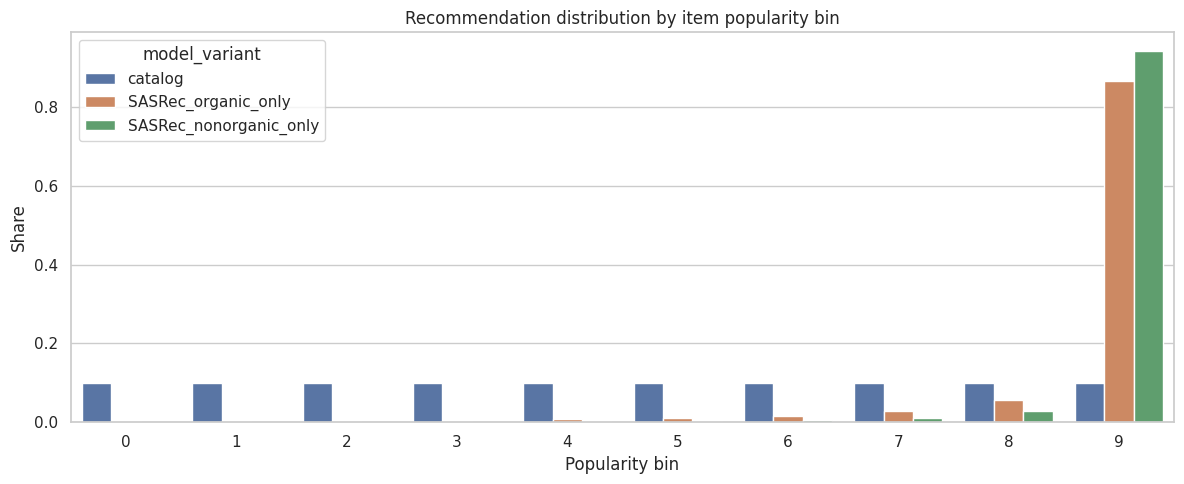

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=rec_bin_dist, x="popularity_bin", y="share", hue="model_variant")
plt.title("Recommendation distribution by item popularity bin")
plt.xlabel("Popularity bin")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

**Вывод:**  Распределение рекомендаций по popularity bins показывает, что обе feedback-модели чаще рекомендуют треки из верхних бинов популярности. Основная концентрация приходится на bin 9, то есть на наиболее популярные треки в train-части. У non-organic-only модели этот сдвиг выражен сильнее: почти вся выдача сосредоточена в самом популярном бине. У organic-only модели концентрация тоже заметна, но распределение немного шире: часть рекомендаций попадает в bins 6–8, то есть модель чаще выходит за пределы самого верхнего сегмента популярности.

Такой результат в целом ожидаем для музыкальных рекомендаций: популярные треки чаще встречаются в историях пользователей, чаще прослушиваются и поэтому получают более сильный обучающий сигнал. Однако это также указывает на риск popularity bias: модель может усиливать уже существующую популярность треков и хуже продвигать менее известные позиции каталога.

В рамках текущего исследования эта проблема фиксируется как важное направление для дальнейшей доработки. Потенциально её можно снижать несколькими способами: добавлять штраф за слишком популярные треки при обучении или ранжировании, отдельно контролировать долю рекомендаций из верхних popularity bins, а также модифицировать attention-механизм так, чтобы модель сильнее учитывала локальные соседства и менее очевидные переходы между треками. Это позволит в дальнейшем сравнивать модели не только по accuracy-метрикам, но и по устойчивости к feedback loop и способности поддерживать более разнообразную выдачу.

## 13. Визуальное сравнение результатов

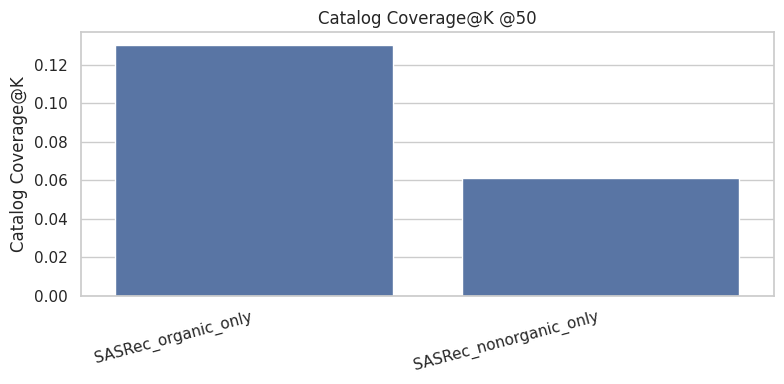

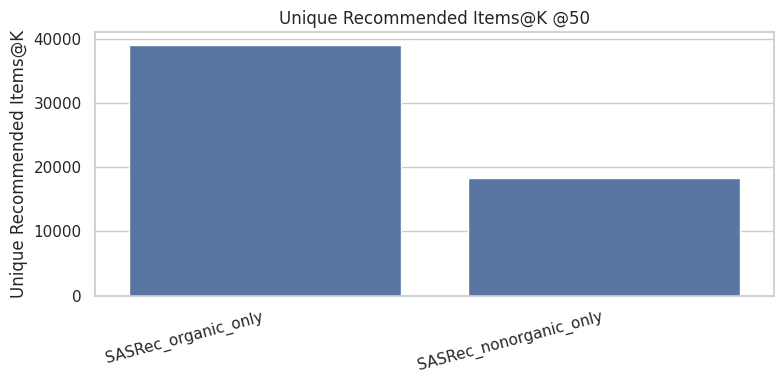

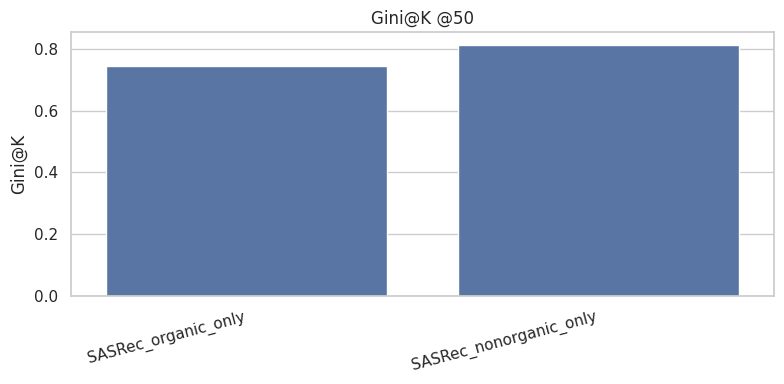

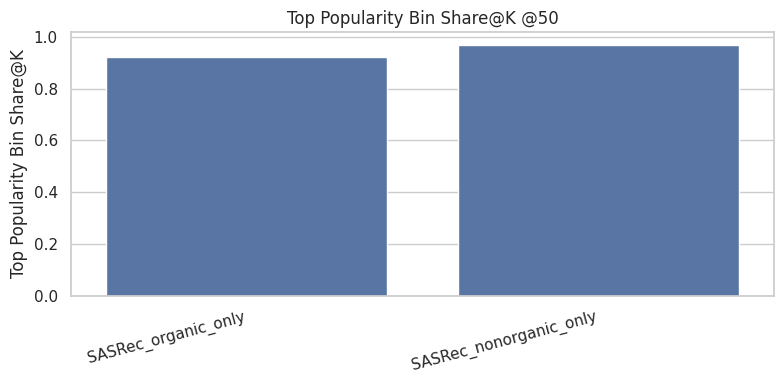

In [ ]:
plot_metrics = ['Catalog Coverage@K', 'Unique Recommended Items@K', 'Gini@K', 'Top Popularity Bin Share@K']

for metric in plot_metrics:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=diversity_results[diversity_results['K'] == MAIN_K], x='model_variant', y=metric)
    plt.title(f'{metric} @{MAIN_K}')
    plt.xlabel('')
    plt.ylabel(metric)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

## 14. Оценка по типу test target: organic / non-organic

На предыдущем шаге сравнивались модели, обученные отдельно на organic и non-organic взаимодействиях. Теперь дополнительно проверим, на каких именно test targets они работают лучше. Для этого к каждой строке с рекомендациями добавляется тип целевого трека: organic target или non-organic target. После этого качество можно сравнить отдельно для двух случаев:

- когда следующий трек пользователя был organic-взаимодействием;
- когда следующий трек пользователя был non-organic-взаимодействием.

Такой разрез нужен, чтобы понять, универсально ли модель улучшает качество или она в основном лучше справляется с тем типом поведения, на котором обучалась.

In [ ]:
test_target_type = test_events[["uid", "item_id", "is_organic"]].copy()
test_target_type = test_target_type.rename(columns={"item_id": "target_item", "is_organic": "target_is_organic"})

In [ ]:
recommendations_with_target_type = recommendations_df.merge(test_target_type, on=["uid", "target_item"], how="left",)
recommendations_with_target_type["target_type"] = np.where(recommendations_with_target_type["target_is_organic"] == 1, "organic_target", "nonorganic_target",)

recommendations_with_target_type.head()

,uid,target_idx,target_item,recommendations,model_variant,target_is_organic,target_type
0,100,293,7415847,"[1143002, 1912005, 155792, 410868, 2419677, 17...",SASRec_organic_only,0,nonorganic_target
1,200,355,2859641,"[8729910, 500245, 4119982, 3763080, 2859641, 3...",SASRec_organic_only,1,organic_target
2,300,60580,8033345,"[6246552, 5805912, 7247939, 8600877, 4094586, ...",SASRec_organic_only,1,organic_target
3,600,778,5148775,"[1441281, 3397170, 1449307, 2996197, 6474571, ...",SASRec_organic_only,0,nonorganic_target
4,700,14457,2439431,"[7801891, 2627621, 2518515, 2188783, 1102135, ...",SASRec_organic_only,0,nonorganic_target


In [ ]:
def hit_metrics_from_recommendations(df, ks=(10, 50)):
    rows = []
    for (model_variant, target_type), group in df.groupby(['model_variant', 'target_type']):
        for k in ks:
            hits, ndcgs, mrrs = [], [], []
            for row in group.itertuples(index=False):
                recs = row.recommendations[:k]
                target = row.target_item
                if target in recs:
                    rank = recs.index(target) + 1
                    hits.append(1)
                    ndcgs.append(1 / np.log2(rank + 1))
                    mrrs.append(1 / rank)
                else:
                    hits.append(0)
                    ndcgs.append(0)
                    mrrs.append(0)

            recall = float(np.mean(hits)) if len(hits) else np.nan
            rows.append({
                'model_variant': model_variant,
                'target_type': target_type,
                'K': k,
                'n_users': len(group),
                'Recall@K': recall,
                'Precision@K': recall / k if pd.notna(recall) else np.nan,
                'NDCG@K': float(np.mean(ndcgs)) if len(ndcgs) else np.nan,
                'MRR@K': float(np.mean(mrrs)) if len(mrrs) else np.nan,
            })
    return pd.DataFrame(rows)

In [ ]:
target_slice_quality = hit_metrics_from_recommendations(recommendations_with_target_type, ks=EVAL_KS)
target_slice_quality

,model_variant,target_type,K,n_users,Recall@K,Precision@K,NDCG@K,MRR@K
0,SASRec_nonorganic_only,nonorganic_target,10,2217,0.041498,0.004150,0.019656,0.013229
1,SASRec_nonorganic_only,nonorganic_target,50,2217,0.118629,0.002373,0.036025,0.016433
2,SASRec_nonorganic_only,organic_target,10,2498,0.055244,0.005524,0.039668,0.034962
3,SASRec_nonorganic_only,organic_target,50,2498,0.108487,0.002170,0.051164,0.037296
4,SASRec_organic_only,nonorganic_target,10,2018,0.015362,0.001536,0.006952,0.004463
5,SASRec_organic_only,nonorganic_target,50,2018,0.043608,0.000872,0.013157,0.005781
6,SASRec_organic_only,organic_target,10,2745,0.290346,0.029035,0.187785,0.156062
7,SASRec_organic_only,organic_target,50,2745,0.409836,0.008197,0.214921,0.162234


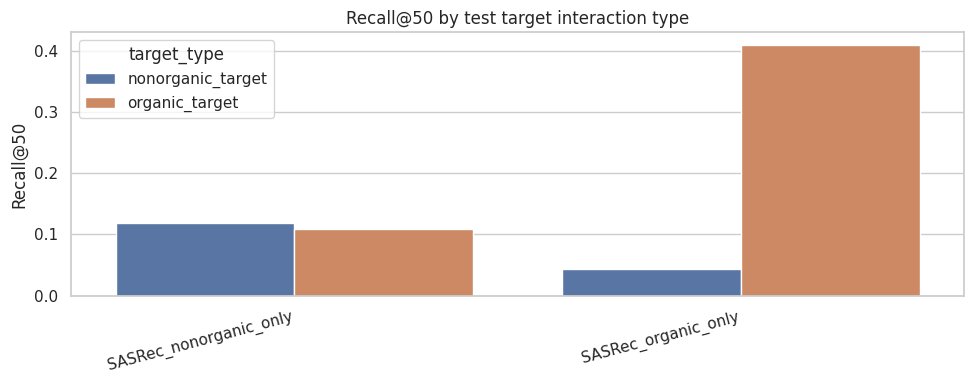

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=target_slice_quality[target_slice_quality["K"] == 50], x="model_variant", y="Recall@K", hue="target_type")
plt.title("Recall@50 by test target interaction type")
plt.xlabel("")
plt.ylabel("Recall@50")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**Вывод:** Разрез по типу test target показывает, что organic-only модель лучше всего предсказывает именно organic targets: Recall@50 достигает примерно 0.410, и это самый высокий результат в таблице. При этом на non-organic targets качество у неё заметно ниже, около 0.044 по Recall@50. Это означает, что organic-сигнал хорошо описывает устойчивое пользовательское поведение, но хуже переносится на события, которые могли быть сильнее связаны с внешними показами или механикой рекомендаций.

Non-organic-only же модель показывает более ровные, но более низкие результаты: Recall@50 около 0.119 на non-organic targets и около 0.108 на organic targets. То есть она лучше organic-only модели на non-organic targets, но существенно проигрывает ей на organic targets.

В целом это подтверждает, что organic и non-organic взаимодействия действительно несут разный сигнал. Organic history лучше подходит для моделирования собственных предпочтений пользователя, а non-organic history может отражать не только интерес пользователя, но и влияние уже существующей рекомендательной системы.

## 15. Итоговые таблицы

В этом разделе собираются ключевые результаты: качество моделей, свойства рекомендаций и качество по типу test target. Основная итоговая таблица строится на @50.

In [ ]:
quality_results

,model_variant,best_epoch,best_val_Recall@50,planned_epochs,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,max_len,max_train_samples_per_user,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@50,Precision@50,NDCG@50,MRR@50,test_samples,train_samples,num_items
0,SASRec_organic_only,30,0.243334,30,128,2,1,0.2,0.0005,0.00001,100,75,0.17384,0.017384,0.111169,0.091832,0.254671,0.005093,0.129437,0.095947,4763,324565,299842
1,SASRec_nonorganic_only,28,0.100954,30,128,2,1,0.2,0.0005,0.00001,100,75,0.04878,0.004878,0.030282,0.024771,0.113256,0.002265,0.044046,0.027486,4715,314268,299842


In [ ]:
diversity_results

,model_variant,K,total_recommendations,Unique Recommended Items@K,Catalog Coverage@K,Gini@K,Top Popularity Bin Share@K,mean_item_popularity,median_item_popularity,long_tail_30pct_bin_share,recommendation_entropy,mean_novelty
0,SASRec_organic_only,10,47630,17922,0.059772,0.568722,0.910771,2014.153979,681.0,0.009112,12.367876,3.436260
1,SASRec_organic_only,50,238150,39085,0.130352,0.745195,0.922011,1988.857077,785.0,0.011568,12.857830,3.237500
2,SASRec_nonorganic_only,10,47150,7735,0.025797,0.735768,0.973340,2156.081421,1146.0,0.004411,10.753078,2.443107
3,SASRec_nonorganic_only,50,235750,18327,0.061122,0.814425,0.969349,1931.355563,1006.0,0.004730,11.688451,2.661864


In [ ]:
target_slice_quality

,model_variant,target_type,K,n_users,Recall@K,Precision@K,NDCG@K,MRR@K
0,SASRec_nonorganic_only,nonorganic_target,10,2217,0.041498,0.004150,0.019656,0.013229
1,SASRec_nonorganic_only,nonorganic_target,50,2217,0.118629,0.002373,0.036025,0.016433
2,SASRec_nonorganic_only,organic_target,10,2498,0.055244,0.005524,0.039668,0.034962
3,SASRec_nonorganic_only,organic_target,50,2498,0.108487,0.002170,0.051164,0.037296
4,SASRec_organic_only,nonorganic_target,10,2018,0.015362,0.001536,0.006952,0.004463
5,SASRec_organic_only,nonorganic_target,50,2018,0.043608,0.000872,0.013157,0.005781
6,SASRec_organic_only,organic_target,10,2745,0.290346,0.029035,0.187785,0.156062
7,SASRec_organic_only,organic_target,50,2745,0.409836,0.008197,0.214921,0.162234


In [ ]:
quality_at50 = quality_results[[
    'model_variant',
    'best_epoch',
    'best_val_Recall@50',
    'Recall@50',
    'Precision@50',
    'NDCG@50',
    'MRR@50',
    'test_samples',
    'train_samples',
    'num_items',
]].copy()

In [ ]:
exposure_at50 = diversity_results[diversity_results['K'] == MAIN_K][[
    'model_variant',
    'Catalog Coverage@K',
    'Unique Recommended Items@K',
    'Gini@K',
    'Top Popularity Bin Share@K',
]].copy()

feedback_summary_at50 = quality_at50.merge(exposure_at50, on='model_variant', how='left')
feedback_summary_at50

,model_variant,best_epoch,best_val_Recall@50,Recall@50,Precision@50,NDCG@50,MRR@50,test_samples,train_samples,num_items,Catalog Coverage@K,Unique Recommended Items@K,Gini@K,Top Popularity Bin Share@K
0,SASRec_organic_only,30,0.243334,0.254671,0.005093,0.129437,0.095947,4763,324565,299842,0.130352,39085,0.745195,0.922011
1,SASRec_nonorganic_only,28,0.100954,0.113256,0.002265,0.044046,0.027486,4715,314268,299842,0.061122,18327,0.814425,0.969349


**Вывод:** Итоговая таблица feedback_summary_at50 объединяет accuracy и exposure-метрики. По ней удобно смотреть главный trade-off: какая модель лучше попадает в test target и одновременно насколько широко она покрывает каталог или, наоборот, концентрируется на популярных треках.

## 16. Сохранение результатов

In [ ]:
output_dir = f'{DATA_DIR}/notebook_5_feedback_loop_outputs'
os.makedirs(output_dir, exist_ok=True)

split_summary.to_csv(f'{output_dir}/split_summary.csv', index=False)
train_subset_summary.to_csv(f'{output_dir}/train_subset_summary.csv', index=False)
feedback_dataset_info.to_csv(f'{output_dir}/feedback_dataset_info.csv', index=False)
quality_results.to_csv(f'{output_dir}/quality_results.csv', index=False)
all_histories.to_csv(f'{output_dir}/feedback_model_histories.csv', index=False)
diversity_results.to_csv(f'{output_dir}/diversity_results.csv', index=False)
rec_bin_dist.to_csv(f'{output_dir}/recommendation_popularity_bin_distribution.csv', index=False)
target_slice_quality.to_csv(f'{output_dir}/target_slice_quality.csv', index=False)
feedback_summary_at50.to_csv(f'{output_dir}/feedback_summary_at50.csv', index=False)
recommendations_df.to_parquet(f'{output_dir}/recommendations.parquet', index=False)

torch.save(organic_model.state_dict(), f'{output_dir}/sasrec_organic_only_model.pt')
torch.save(nonorganic_model.state_dict(), f'{output_dir}/sasrec_nonorganic_only_model.pt')

with open(f'{output_dir}/sasrec_feedback_config.json', 'w') as f:
    json.dump(SASREC_CONFIG, f, indent=4)

with open(f'{output_dir}/common_item2idx.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in common_item2idx.items()}, f)
with open(f'{output_dir}/common_idx2item.json', 'w') as f:
    json.dump({str(k): str(v) for k, v in organic_idx2item.items()}, f)

print('Saved outputs to:', output_dir)

Saved outputs to: /content/drive/MyDrive/Курсовая/final_subsample/notebook_5_feedback_loop_outputs
